In [2]:
import sys
import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import norm

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.models.xgboost_model import *
from src.models.ngboost_model import *

/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pd.set_option('display.max_columns', None)

s22 = pd.read_csv('/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/processed/training/PTS_TRAIN_22.csv')
s23 = pd.read_csv('/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/processed/training/PTS_TRAIN_23.csv')
s24 = pd.read_csv('/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/processed/training/PTS_TRAIN_24.csv')
s25 = pd.read_csv('/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/processed/training/PTS_TRAIN_25.csv')
s26 = pd.read_csv('/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/processed/training/PTS_TRAIN_26.csv')

for df in [s22,s23,s24,s25,s26]:
    df['STARTING_X_MIN'] = df['STARTING'] * df['MIN_AVG_TO_DATE']
    df['STARTING_X_USG_PCT'] = df['STARTING'] * df['USG_PCT_AVG_TO_DATE']
    df['STARTING_X_FGA'] = df['STARTING'] * df['FGA_AVG_TO_DATE']
    df['STARTING_X_PTS'] = df['STARTING'] * df['PTS_AVG_TO_DATE']


train_df = pd.concat([s22,s23,s24,s25])
val_df = s26

print("BEFORE FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
train_df.sample()


BEFORE FILTERING:
Train set: 104668 samples
Val set: 7469 samples


,Unnamed: 0,Unnamed: 0.1,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FGM_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG3M_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FTM_ROLLING_AVG_3,UFGA_ROLLING_AVG_3,UFGM_ROLLING_AVG_3,CFGA_ROLLING_AVG_3,CFGM_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,MIN_ROLLING_AVG_3,POSS_ROLLING_AVG_3,PLUS_MINUS_ROLLING_AVG_3,TS_PCT_ROLLING_AVG_3,SPD_ROLLING_AVG_3,PF_ROLLING_AVG_3,PASS_ROLLING_AVG_3,SAST_ROLLING_AVG_3,AST_ROLLING_AVG_3,REB_ROLLING_AVG_3,OREB_ROLLING_AVG_3,DREB_ROLLING_AVG_3,TOV_ROLLING_AVG_3,E_OFF_RATING_ROLLING_AVG_3,NET_RATING_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,TCHS_ROLLING_AVG_3,FG_PCT_ROLLING_AVG_3,FG3_PCT_ROLLING_AVG_3,FT_PCT_ROLLING_AVG_3,PTS_OFF_TOV_ROLLING_AVG_3,PTS_2ND_CHANCE_ROLLING_AVG_3,PTS_FB_ROLLING_AVG_3,PTS_PAINT_ROLLING_AVG_3,PTS_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,UFGA_ROLLING_AVG_5,UFGM_ROLLING_AVG_5,CFGA_ROLLING_AVG_5,CFGM_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,POSS_ROLLING_AVG_5,PLUS_MINUS_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,SPD_ROLLING_AVG_5,PF_ROLLING_AVG_5,PASS_ROLLING_AVG_5,SAST_ROLLING_AVG_5,AST_ROLLING_AVG_5,REB_ROLLING_AVG_5,OREB_ROLLING_AVG_5,DREB_ROLLING_AVG_5,TOV_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,PTS_OFF_TOV_ROLLING_AVG_5,PTS_2ND_CHANCE_ROLLING_AVG_5,PTS_FB_ROLLING_AVG_5,PTS_PAINT_ROLLING_AVG_5,PTS_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FGM_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG3M_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FTM_ROLLING_AVG_7,UFGA_ROLLING_AVG_7,UFGM_ROLLING_AVG_7,CFGA_ROLLING_AVG_7,CFGM_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,POSS_ROLLING_AVG_7,PLUS_MINUS_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,SPD_ROLLING_AVG_7,PF_ROLLING_AVG_7,PASS_ROLLING_AVG_7,SAST_ROLLING_AVG_7,AST_ROLLING_AVG_7,REB_ROLLING_AVG_7,OREB_ROLLING_AVG_7,DREB_ROL

In [4]:
player_season_avg = train_df.groupby('PLAYER_ID').agg({
    'MIN': 'mean',
    'PTS': 'mean',
    'GAMES_PLAYED_TO_DATE': 'max'
}).reset_index()

player_season_avg.columns = ['PLAYER_ID', 'MIN_AVG', 'PTS_AVG', 'GAMES_PLAYED']

# Define criteria for "relevant players"
relevant_players = player_season_avg[
    (player_season_avg['MIN_AVG'] >= 10) &      
    (player_season_avg['GAMES_PLAYED'] >= 5)
]['PLAYER_ID']

# Filter training data to only relevant players
train_df = train_df[train_df['PLAYER_ID'].isin(relevant_players)]
train_df = train_df[
    (train_df['PTS'] >= 0) &  
    (train_df['PTS'] <= 55) &  
    (train_df['MIN'] >= 5) &  
    (train_df['MIN'] <= 48) &
    (train_df['USG_PCT'] >= 0.05) & 
    (train_df['USG_PCT'] <= 0.45)
]
train_df = train_df.dropna(subset=['PTS_ROLLING_AVG_3'])

val_df = val_df[val_df['PLAYER_ID'].isin(relevant_players)]
val_df = val_df[
    (val_df['PTS'] >= 0) &
    (val_df['PTS'] <= 55) &
    (val_df['MIN'] >= 5) &
    (val_df['MIN'] <= 48) &
    (val_df['USG_PCT'] >= 0.05) &
    (val_df['USG_PCT'] <= 0.45)
]
val_df = val_df.dropna(subset=['PTS_ROLLING_AVG_3'])

print("AFTER FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")


AFTER FILTERING:
Train set: 89430 samples
Val set: 5392 samples


In [5]:
MIN_features = [
    'STARTING_X_MIN',
    'STAR_SAT_OUT',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'B2B_X_MIN', 
    'PLAYER_MISSED_LAST_GAME_X_MIN', 
    
    'PERCENTAGE_OF_TEAM_MIN',
    'MIN_TEAM_RANK',

    'MIN_CEILING_L5_DELTA',
    'MIN_FLOOR_L5_DELTA',
    'STARTING_x_MIN_AVG',
    'STARTING_x_MIN_CEILING',
    'HIGH_MIN_PLAYER',
    'MEDIUM_MIN_PLAYER',
    'LOW_MIN_PLAYER',
    'MIN_AVG_TO_DATE',
    'MIN_L5_OVER_BASELINE',
    'MIN_STD_5_TO_DATE',
    'MIN_BOOST_STAR_OUT',
    'MIN_EXPECTATION_LOCATION',
    'MATCHUP_MIN_DELTA',


    'TEAM_PACE_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',
    'EXPECTED_PACE_X_MIN', #new

    'OPP_DEF_RATING_OVER_LEAGUE_AVG',
    'OPP_DEF_RATING_OVER_LEAGUE_x_MIN', #new
    'OPP_PACE_OVER_LEAGUE_AVG',
]
MIN_target = 'MIN'

In [6]:
USG_features = [
    'STARTING_X_USG_PCT', #new
    'USG_TEAM_RANK',

    'PLAYER_IS_TEAM_STAR',
    'USG_PCT_BOOST_STAR_OUT',
    'LINEUP_FGA_SHARE_AVG', 
    'USG_PCT_AVG_TO_DATE', 
    'USG_PCT_L5_OVER_BASELINE',
    'PASSES_PER_TOUCHES',
    'TCHS_AVG_TO_DATE',

    'EXPECTED_PACE_X_USG_PCT', #new
    'OPP_DEF_RATING_OVER_LEAGUE_x_USG_PCT'
]
USG_target = 'USG_PCT'
print(f"len(USG_features): {len(USG_features)}")

len(USG_features): 11


In [7]:
FGA_features = [
    # Core identifiers
    'STARTING_X_FGA', #new
    'GAMES_PLAYED_TO_DATE',
    
    # Player type
    'HIGH_FGA_PLAYER', 
    'MEDIUM_FGA_PLAYER',
    'LOW_FGA_PLAYER',

    'FGA_TEAM_RANK', #new
    'PERCENTAGE_OF_TEAM_FGA', #new

    # Baseline shot volume
    'FGA_AVG_TO_DATE',
    'FGA_STD_5_TO_DATE',
    'FGA_L5_OVER_BASELINE', 
    
    # Situational boosts
    'FGA_BOOST_STAR_OUT',
    'FGA_EXPECTATION_LOCATION',
    
    # Shot types
    'CFGA_AVG_TO_DATE', 
    'UFGA_AVG_TO_DATE',  
    'UFGA_L5_OVER_BASELINE',  
    
    # Three-point volume
    'FG3A_AVG_TO_DATE',
    'FG3A_L5_OVER_BASELINE',
    'FG3A_BOOST_STAR_OUT',
    
    # Efficiency (affects green light)
    'FG_PCT_AVG_TO_DATE',
    'FG_PCT_L5_OVER_BASELINE',
    'TS_PCT_AVG_TO_DATE',
    'TS_PCT_L5_OVER_BASELINE',
    
    # Aggression/playmaking
    'FTA_AVG_TO_DATE',
    'FTA_L5_OVER_BASELINE',
    'AST_AVG_TO_DATE',  
    'TOV_AVG_TO_DATE',  
    
    # Variance stability
    'FGA_VARIANCE_STABILITY',
    'FG3A_VARIANCE_STABILITY',
    
    # Team context
    'TEAM_OFF_RATING_OVER_LEAGUE_AVG',
    'TEAM_PACE_OVER_LEAGUE_AVG',
    
    # Game pace
    'EXPECTED_PACE',
    'OPP_PACE_OVER_LEAGUE_AVG',
    
    # Opponent defense
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',
    'GUARD_DEF_RATING_OVER_LEAGUE_AVG',
    'FORWARD_DEF_RATING_OVER_LEAGUE_AVG',
    'OPP_DEF_RATING_OVER_LEAGUE_AVG_x_FGA_AVG_TO_DATE',

    # Predicted upstream values
    'PREDICTED_MIN_x_PREDICTED_USG_PCT',
    'PREDICTED_USG_PCT_x_TEAM_PACE_OVER_LEAGUE_AVG',
    'FGA_BOOST_STAR_OUT_x_PREDICTED_USG_PCT',
    'EXPECTED_PACE_x_PREDICTED_MIN',
]
FGA_target = 'FGA'

In [8]:
# Train cascading model: MIN -> USG_PCT -> FGA -> PTS
cascading_models = train_cascading_model(
    train_data=train_df,
    val_data=val_df,
    min_features=MIN_features,
    usg_features=USG_features,
    fga_features=FGA_features,
    date_column='GAME_DATE',
    player_column='PLAYER_ID'
)

# Extract models and metrics
min_model = cascading_models['min_model']
usg_model = cascading_models['usg_model']
fga_model = cascading_models['fga_model']
metrics = cascading_models['metrics']


Training XGBoost Model
Validation - RMSE: 5.323, MAE: 4.099, R²: 0.632
Training XGBoost Model
Validation - RMSE: 0.053, MAE: 0.042, R²: 0.458
Training XGBoost Model
Validation - RMSE: 3.396, MAE: 2.600, R²: 0.646

MIN Model - RMSE: 5.323, MAE: 4.099, R²: 0.632
USG_PCT Model - RMSE: 0.053, MAE: 0.042, R²: 0.458
FGA Model - RMSE: 3.396, MAE: 2.600, R²: 0.646


In [9]:
def add_predictions(df, min_model, usg_model, fga_model, min_features, usg_features, fga_features):
    """Add predicted MIN, USG_PCT and FGAto dataframe using trained models"""
    df = df.copy()
    
    # Predict MIN first
    X_min = df[min_features].fillna(0)
    df['PREDICTED_MIN'] = min_model.predict(X_min)
    
    # Predict USG using predicted MIN
    X_usg = df[usg_features].copy()
    X_usg['PREDICTED_MIN'] = df['PREDICTED_MIN']
    X_usg = X_usg.fillna(0)
    df['PREDICTED_USG_PCT'] = usg_model.predict(X_usg)

    # interaction features for FGA model
    df['PREDICTED_USG_PCT_x_TEAM_PACE_OVER_LEAGUE_AVG'] = (
        df['PREDICTED_USG_PCT'] * df['TEAM_PACE_OVER_LEAGUE_AVG']
    )
    df['FGA_BOOST_STAR_OUT_x_PREDICTED_USG_PCT'] = (
        df['FGA_BOOST_STAR_OUT'] * df['PREDICTED_USG_PCT']
    )
    df['EXPECTED_PACE_x_PREDICTED_MIN'] = (
        df['EXPECTED_PACE'] * df['PREDICTED_MIN']
    )
    df['PREDICTED_MIN_x_PREDICTED_USG_PCT'] = (
        df['PREDICTED_MIN'] * df['PREDICTED_USG_PCT']
    )

    # Predict FGA using predicted MIN and USG (and interaction features)
    X_fga = df[fga_features].copy()
    X_fga['PREDICTED_MIN'] = df['PREDICTED_MIN']
    X_fga['PREDICTED_USG_PCT'] = df['PREDICTED_USG_PCT']
    X_fga = X_fga.fillna(0)
    df['PREDICTED_FGA'] = fga_model.predict(X_fga)
    return df

train_df_with_preds = add_predictions(train_df, min_model, usg_model, fga_model, MIN_features, USG_features, FGA_features)
val_df_with_preds = add_predictions(val_df, min_model, usg_model, fga_model, MIN_features, USG_features, FGA_features)


Top 25 Features by SHAP importance:
  STARTING_x_MIN_CEILING         2.8159
  STARTING_X_MIN                 1.6796
  MIN_TEAM_RANK                  1.5071
  PERCENTAGE_OF_TEAM_MIN         1.0738
  MIN_AVG_TO_DATE                0.7255
  MIN_BOOST_STAR_OUT             0.5599
  EXPECTED_PACE_X_MIN            0.4632
  MIN_L5_OVER_BASELINE           0.3164
  STARTING_x_MIN_AVG             0.3045
  OPP_DEF_RATING_OVER_LEAGUE_x_MIN 0.2813
  PLAYER_MISSED_LAST_GAME_X_MIN  0.2229
  MIN_EXPECTATION_LOCATION       0.1770
  MIN_FLOOR_L5_DELTA             0.1573
  PLAYER_DAYS_REST               0.1518
  EXPECTED_PACE                  0.1436
  OPP_DEF_RATING_OVER_LEAGUE_AVG 0.1409
  MIN_STD_5_TO_DATE              0.1391
  MIN_CEILING_L5_DELTA           0.1290
  USUAL_STARTERS_AVAILABLE       0.1270
  TEAM_PACE_OVER_LEAGUE_AVG      0.1133
  MATCHUP_MIN_DELTA              0.1057
  STAR_SAT_OUT                   0.0878
  OPP_PACE_OVER_LEAGUE_AVG       0.0720
  B2B_X_MIN                      0.0502
  

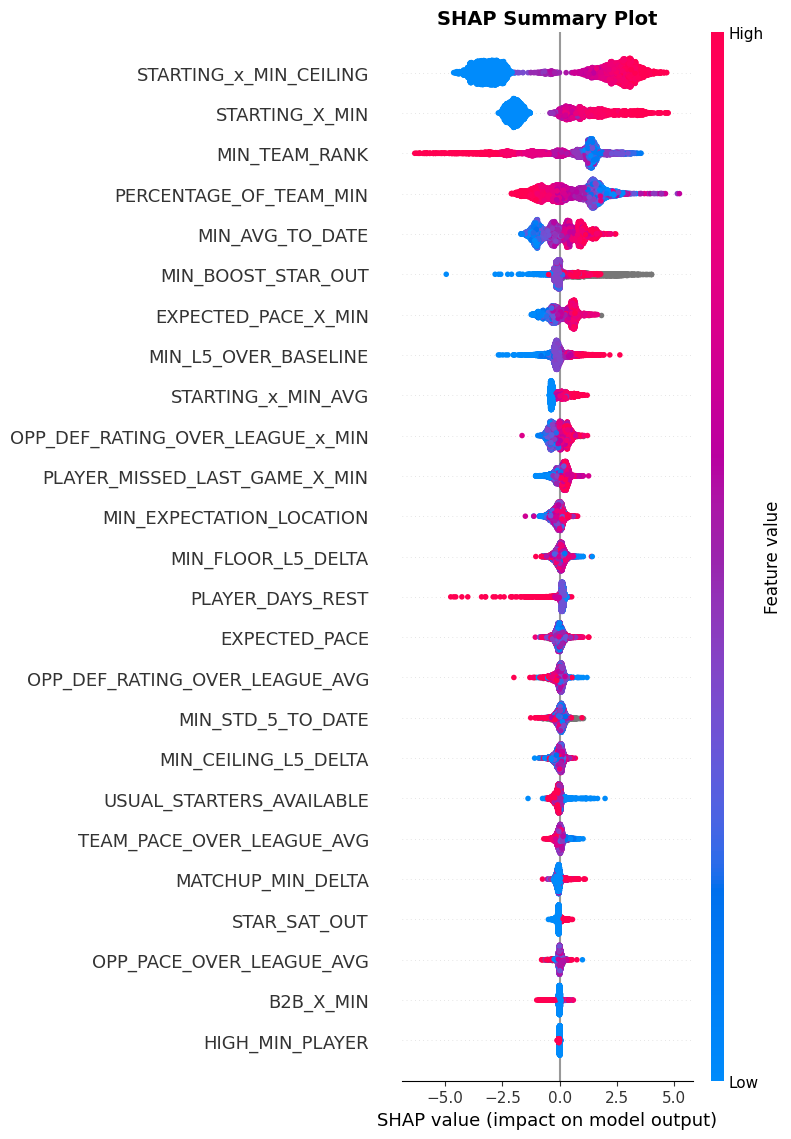

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
analyze_shap(min_model, val_df_with_preds, MIN_features, 'MIN')

Top 25 Features by SHAP importance:
  USG_PCT_AVG_TO_DATE            0.0142
  USG_TEAM_RANK                  0.0106
  EXPECTED_PACE_X_USG_PCT        0.0066
  STARTING_X_USG_PCT             0.0048
  OPP_DEF_RATING_OVER_LEAGUE_x_USG_PCT 0.0047
  USG_PCT_BOOST_STAR_OUT         0.0022
  LINEUP_FGA_SHARE_AVG           0.0015
  USG_PCT_L5_OVER_BASELINE       0.0011
  TCHS_AVG_TO_DATE               0.0010
  PREDICTED_MIN                  0.0007
  PLAYER_IS_TEAM_STAR            0.0007
  PASSES_PER_TOUCHES             0.0004


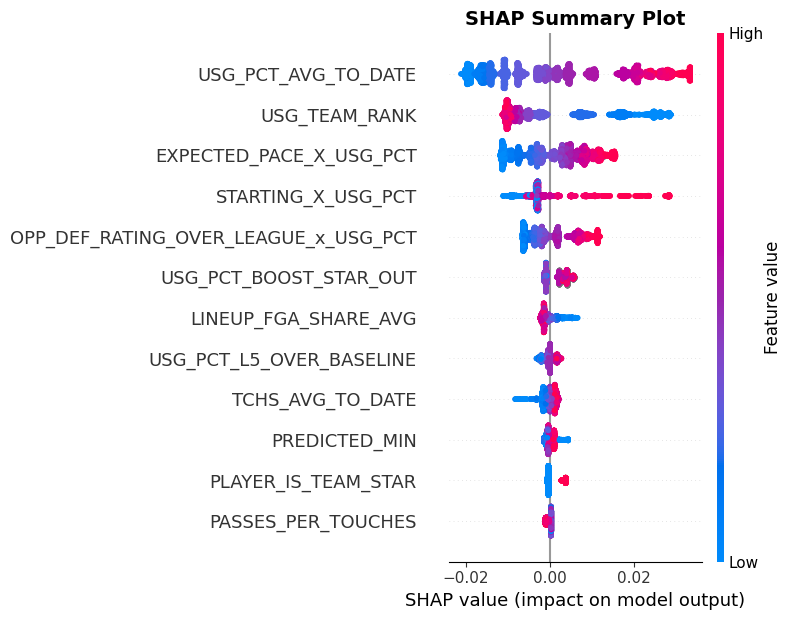

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [11]:
analyze_shap(usg_model, val_df_with_preds, USG_features, 'USG_PCT')

Top 25 Features by SHAP importance:
  PREDICTED_MIN_x_PREDICTED_USG_PCT 3.2891
  EXPECTED_PACE_x_PREDICTED_MIN  0.3923
  STARTING_X_FGA                 0.2639
  TOV_AVG_TO_DATE                0.2557
  FGA_TEAM_RANK                  0.2236
  FGA_BOOST_STAR_OUT             0.2235
  FTA_AVG_TO_DATE                0.1946
  PREDICTED_MIN                  0.1607
  EXPECTED_PACE                  0.1507
  PREDICTED_USG_PCT              0.1423
  PREDICTED_USG_PCT_x_TEAM_PACE_OVER_LEAGUE_AVG 0.1071
  PERCENTAGE_OF_TEAM_FGA         0.1016
  FGA_STD_5_TO_DATE              0.0966
  GUARD_DEF_RATING_OVER_LEAGUE_AVG 0.0957
  FGA_BOOST_STAR_OUT_x_PREDICTED_USG_PCT 0.0942
  FG3A_AVG_TO_DATE               0.0899
  AST_AVG_TO_DATE                0.0768
  CFGA_AVG_TO_DATE               0.0760
  TEAM_OFF_RATING_OVER_LEAGUE_AVG 0.0695
  UFGA_AVG_TO_DATE               0.0664
  FGA_L5_OVER_BASELINE           0.0653
  FGA_AVG_TO_DATE                0.0652
  OPP_DEF_RATING_OVER_LEAGUE_AVG 0.0550
  FG3A_BOOST_ST

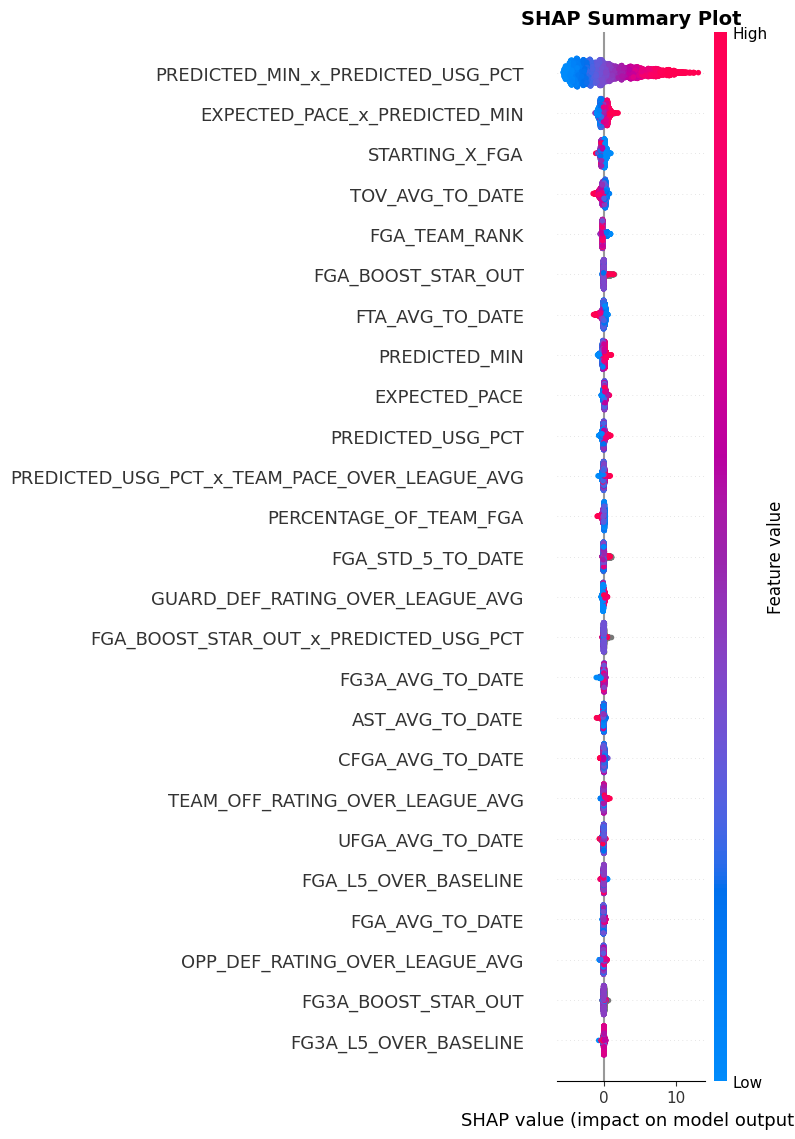

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
analyze_shap(fga_model, val_df_with_preds, FGA_features, 'FGA')

In [13]:
PTS_features = [
    'STARTING_X_PTS', #new
    'GAMES_PLAYED_TO_DATE',
    'PTS_CEILING_L5_DELTA',

    # Predicted upstream values and interaction features (most important)
    'PREDICTED_MIN',
    'PREDICTED_USG_PCT',
    'PREDICTED_FGA', 
    'PREDICTED_MIN_x_PREDICTED_USG_PCT',
    'PTS_PER_MIN',
    'PTS_L5_OVER_BASELINE_x_PREDICTED_MIN',
    'EXPECTED_PACE_x_PREDICTED_USG_PCT',
    'EXPECTED_PACE_x_PREDICTED_FGA',
    'PREDICTED_FGA_x_TS_PCT_AVG_TO_DATE',
    'OPP_DEF_RATING_OVER_LEAGUE_AVG_x_PTS_AVG_TO_DATE',

    'PTS_TEAM_RANK', #new
    'PERCENTAGE_OF_TEAM_PTS', #new
    
    'PTS_AVG_TO_DATE',
    'PTS_STD_5_TO_DATE',
    'PTS_BOOST_STAR_OUT',
    'PTS_EXPECTATION_LOCATION',
    
    'CFGA_AVG_TO_DATE',  
    'UFGA_AVG_TO_DATE', 
    'UFGA_L5_OVER_BASELINE',
    
    'FTA_AVG_TO_DATE',
    'FTA_L5_OVER_BASELINE',
    'FTA_BOOST_STAR_OUT',
    'FTA_EXPECTATION_LOCATION',
    'FG3A_AVG_TO_DATE',
    'FG3A_L5_OVER_BASELINE',
    'FG3A_BOOST_STAR_OUT',
    
    'PLUS_MINUS_AVG_TO_DATE',
    'PLUS_MINUS_BOOST_STAR_OUT',
    
    'FG_PCT_AVG_TO_DATE',
    'FG_PCT_L5_OVER_BASELINE',
    
    'FG3_PCT_AVG_TO_DATE',
    'MATCHUP_FG3_PCT_DELTA',
    
    'FT_PCT_AVG_TO_DATE',
    'FT_PCT_BOOST_STAR_OUT',
    
    'TS_PCT_AVG_TO_DATE',
    'TS_PCT_BOOST_STAR_OUT',
    
    'PTS_VARIANCE_STABILITY',
    'FGA_VARIANCE_STABILITY',
    'FTA_VARIANCE_STABILITY',
    'FG3A_VARIANCE_STABILITY',
    'TS_PCT_VARIANCE_STABILITY',
    
    'TEAM_OFF_RATING_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',
    
    'GUARD_DEF_RATING_OVER_LEAGUE_AVG',
    'FORWARD_DEF_RATING_OVER_LEAGUE_AVG',
]


In [14]:
# interaction term
train_df_with_preds['PREDICTED_MIN_x_PREDICTED_USG_PCT'] = (
    train_df_with_preds['PREDICTED_MIN'] * train_df_with_preds['PREDICTED_USG_PCT']
)
val_df_with_preds['PREDICTED_MIN_x_PREDICTED_USG_PCT'] = (
    val_df_with_preds['PREDICTED_MIN'] * val_df_with_preds['PREDICTED_USG_PCT']
)
train_df_with_preds['EXPECTED_PACE_x_PREDICTED_USG_PCT'] = (
    train_df_with_preds['EXPECTED_PACE'] * train_df_with_preds['PREDICTED_USG_PCT']
)
val_df_with_preds['EXPECTED_PACE_x_PREDICTED_USG_PCT'] = (
    val_df_with_preds['EXPECTED_PACE'] * val_df_with_preds['PREDICTED_USG_PCT']
)
train_df_with_preds['EXPECTED_PACE_x_PREDICTED_FGA'] = (
    train_df_with_preds['EXPECTED_PACE'] * train_df_with_preds['PREDICTED_FGA']
)
val_df_with_preds['EXPECTED_PACE_x_PREDICTED_FGA'] = (
    val_df_with_preds['EXPECTED_PACE'] * val_df_with_preds['PREDICTED_FGA']
)
train_df_with_preds['PTS_L5_OVER_BASELINE_x_PREDICTED_MIN'] = (
    train_df_with_preds['PTS_L5_OVER_BASELINE'] * train_df_with_preds['PREDICTED_MIN']
)
val_df_with_preds['PTS_L5_OVER_BASELINE_x_PREDICTED_MIN'] = (
    val_df_with_preds['PTS_L5_OVER_BASELINE'] * val_df_with_preds['PREDICTED_MIN']
)
train_df_with_preds['PTS_PER_MIN'] = (
    train_df_with_preds['PTS_AVG_TO_DATE'] / train_df_with_preds['PREDICTED_MIN']
)
val_df_with_preds['PTS_PER_MIN'] = (
    val_df_with_preds['PTS_AVG_TO_DATE'] / val_df_with_preds['PREDICTED_MIN']
)
train_df_with_preds['PREDICTED_FGA_x_TS_PCT_AVG_TO_DATE'] = (
    train_df_with_preds['PREDICTED_FGA'] * train_df_with_preds['TS_PCT_AVG_TO_DATE']
)
val_df_with_preds['PREDICTED_FGA_x_TS_PCT_AVG_TO_DATE'] = (
    val_df_with_preds['PREDICTED_FGA'] * val_df_with_preds['TS_PCT_AVG_TO_DATE']
)
train_df_pts = train_df_with_preds[['PTS', 'PLAYER_ID'] + PTS_features].copy()
val_df_pts = val_df_with_preds[['PTS', 'PLAYER_ID'] + PTS_features].copy()

print(f"\nPreparing feature matrices...")
print(f"Training samples: {len(train_df_pts)}")
print(f"Validation samples: {len(val_df_pts)}")
print(f"Features: {len(PTS_features)}")
print(f"Points range: {train_df_pts['PTS'].min()} - {train_df_pts['PTS'].max()}")
print(f"Mean points: {train_df_pts['PTS'].mean():.2f}")


Preparing feature matrices...
Training samples: 89430
Validation samples: 5392
Features: 48
Points range: 0 - 55
Mean points: 11.97


In [15]:
pts_model = train_ngboost_model(train_df_pts, val_df_pts, PTS_features, 'PTS', n_estimators=500)

Using passed validation data to check for early stopping.


In [ ]:
y_pred = predict_mean(pts_model, val_df_pts, PTS_features, variance_calibration={'low': 1.15, 'medium': 0.85, 'high': 0.95}, return_type='Median')
y_actual = val_df_pts['PTS'].values

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"PTS Model Metrics: MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")
print(f"Predicted: {y_pred.mean():.2f} ± {y_pred.std():.2f} | Actual: {y_actual.mean():.2f} ± {y_actual.std():.2f}")

PTS Model Metrics: MAE=4.055 | RMSE=5.275 | R²=0.647
Predicted: 12.18 ± 6.57 | Actual: 12.49 ± 8.88


In [ ]:
analyze_ngboost_shap(pts_model, val_df_pts, PTS_features, sample_size=1000)

In [44]:
mean_log, scale_log, var_log = get_distribution_params(
    pts_model, val_df_pts, PTS_features,
    variance_calibration={'low': 1.15, 'medium': 0.85, 'high': 0.95}  # ← Adjusted
)

# Use MEDIAN for point prediction (not mean)
predictions = np.expm1(mean_log)  # ← Changed: this is the median

# Sample (same as before)
samples_log = np.random.normal(
    mean_log[:, np.newaxis], 
    scale_log[:, np.newaxis], 
    size=(len(mean_log), 10000)
)
samples = np.expm1(samples_log)
percentiles = np.percentile(samples, [5, 25, 50, 75, 95], axis=1)

In [45]:
# Check calibration quality
actuals = val_df_pts['PTS'].values

in_90 = ((actuals >= percentiles[0]) & (actuals <= percentiles[4])).mean()
in_50 = ((actuals >= percentiles[1]) & (actuals <= percentiles[3])).mean()
below_median = (actuals < percentiles[2]).mean()

print("\nCalibration Quality:")
print(f"  90% interval coverage: {in_90:.1%} (target: 90%)")
print(f"  50% interval coverage: {in_50:.1%} (target: 50%)")
print(f"  Below median: {below_median:.1%} (target: 50%)")

# By bin
for bin_name, (low, high) in [('Low', (0, 7)), ('Med', (7, 15)), ('High', (15, 100))]:
    mask = (predictions >= low) & (predictions < high)
    if mask.sum() > 0:
        bin_actuals = actuals[mask]
        bin_in_90 = ((bin_actuals >= percentiles[0][mask]) & 
                     (bin_actuals <= percentiles[4][mask])).mean()
        print(f"  {bin_name}: {bin_in_90:.1%} in 90% interval")


Calibration Quality:
  90% interval coverage: 90.2% (target: 90%)
  50% interval coverage: 50.5% (target: 50%)
  Below median: 40.5% (target: 50%)
  Low: 90.3% in 90% interval
  Med: 90.1% in 90% interval
  High: 90.3% in 90% interval


In [54]:
# Detailed diagnostic
actuals = val_df_pts['PTS'].values

print("\n" + "="*60)
print("DETAILED DIAGNOSTIC")
print("="*60)

# 1. Check if predictions == percentiles[2]
print(f"\nPredictions vs Percentiles[2] (median):")
print(f"  predictions mean: {predictions.mean():.2f}")
print(f"  percentiles[2] mean: {percentiles[2].mean():.2f}")
print(f"  Difference: {(predictions - percentiles[2]).mean():.4f}")
print(f"  Max diff: {np.abs(predictions - percentiles[2]).max():.4f}")

# 2. Check actual distribution
print(f"\nActual vs Predicted distribution:")
print(f"  Actual mean: {actuals.mean():.2f}")
print(f"  Actual median: {np.median(actuals):.2f}")
print(f"  Predicted median: {predictions.mean():.2f}")

# 3. Check by bin
print(f"\nBelow median by bin:")
bins = [(0, 7), (7, 15), (15, 100)]
for name, (low, high) in [('Low', bins[0]), ('Med', bins[1]), ('High', bins[2])]:
    mask = (predictions >= low) & (predictions < high)
    if mask.sum() > 0:
        bin_below = (actuals[mask] < predictions[mask]).mean()
        bin_actuals_mean = actuals[mask].mean()
        bin_preds_mean = predictions[mask].mean()
        print(f"  {name}: {bin_below:.1%} below median (actual: {bin_actuals_mean:.1f}, pred: {bin_preds_mean:.1f})")

# 4. Look at residuals
residuals = predictions - actuals
print(f"\nResiduals (pred - actual):")
print(f"  Mean: {residuals.mean():.2f}")
print(f"  Median: {np.median(residuals):.2f}")
print(f"  This tells us predictions are systematically {'high' if residuals.mean() > 0 else 'low'}")


DETAILED DIAGNOSTIC

Predictions vs Percentiles[2] (median):
  predictions mean: 10.92
  percentiles[2] mean: 10.92
  Difference: -0.0007
  Max diff: 0.2664

Actual vs Predicted distribution:
  Actual mean: 12.49
  Actual median: 11.00
  Predicted median: 10.92

Below median by bin:
  Low: 40.9% below median (actual: 5.7, pred: 4.5)
  Med: 40.5% below median (actual: 12.1, pred: 10.5)
  High: 39.4% below median (actual: 22.6, pred: 20.6)

Residuals (pred - actual):
  Mean: -1.57
  Median: -1.06
  This tells us predictions are systematically low


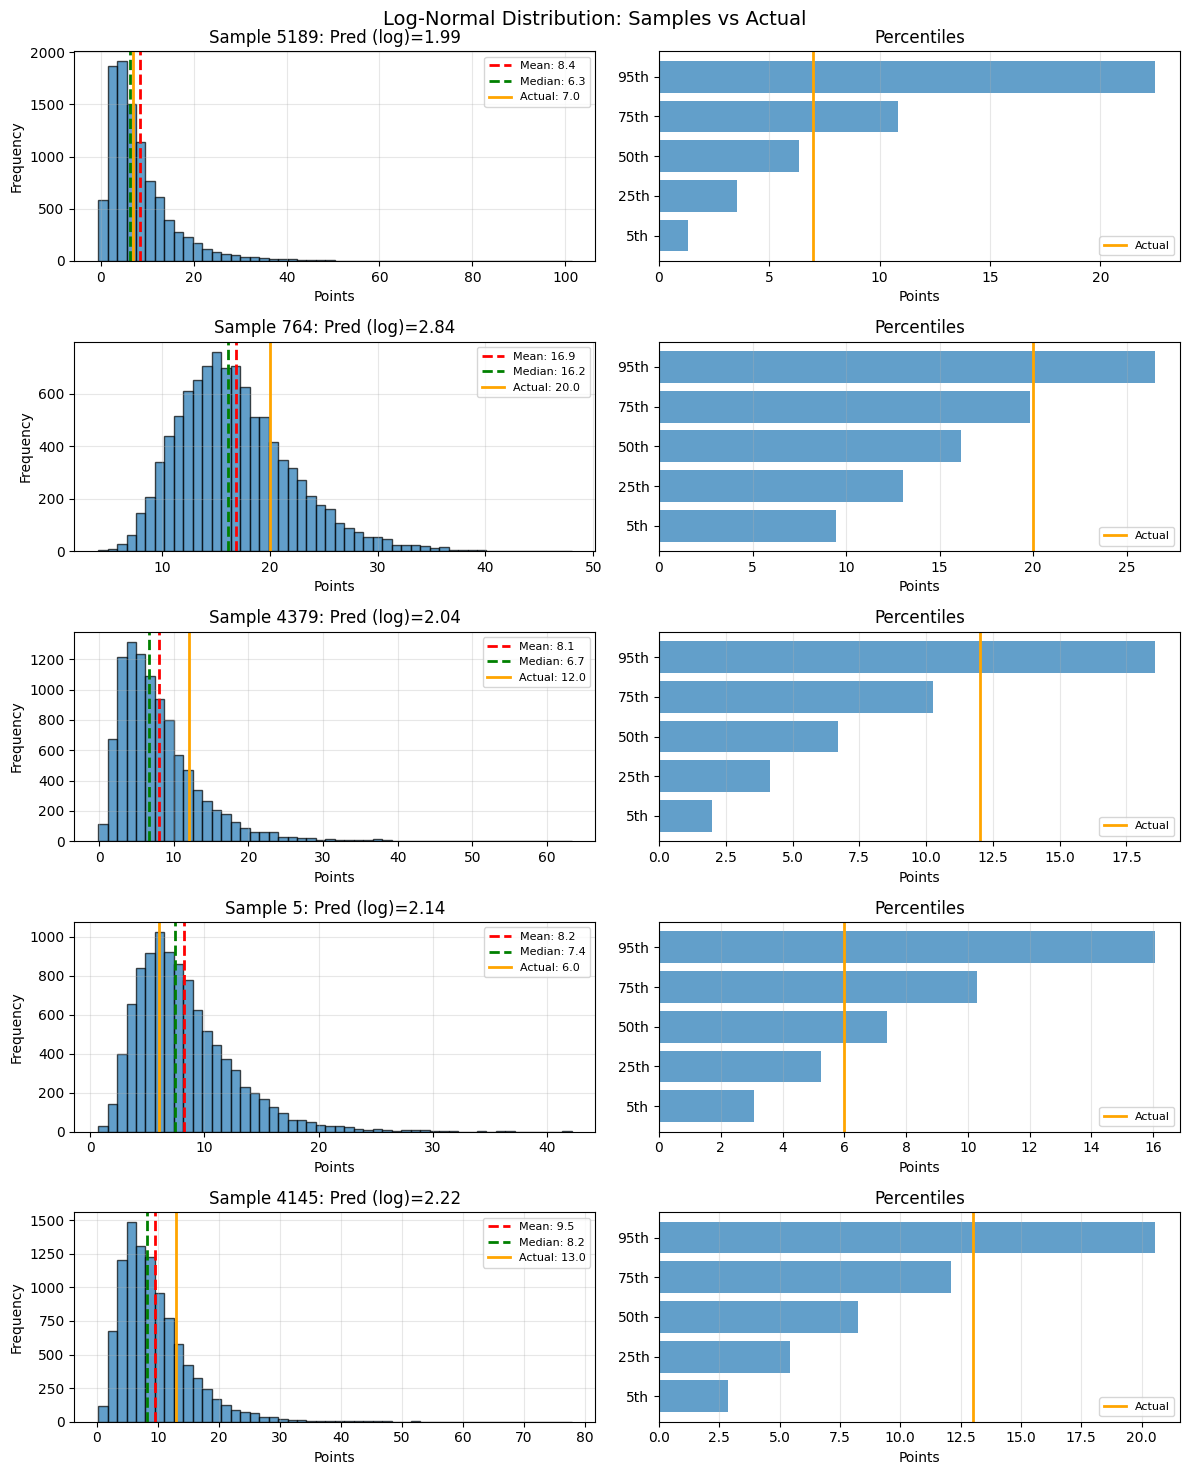

Distribution Summary
Mean Variance (log space): 0.2785
Mean Std Dev (log space): 0.5008

Sample Statistics:
  Mean of predictions: 10.92
  Std of predictions: 6.74
  Actual mean: 12.49
  Actual std: 8.88

Percentile Ranges (across all predictions):
  5th-95th: 5.2 - 23.4
  25th-75th: 8.0 - 14.9


In [48]:
import matplotlib.pyplot as plt

n_examples = 5
example_indices = np.random.choice(len(mean_log), n_examples, replace=False)

fig, axes = plt.subplots(n_examples, 2, figsize=(12, 3*n_examples))
fig.suptitle('Log-Normal Distribution: Samples vs Actual', fontsize=14)

for idx, ax_row in zip(example_indices, axes):
    ax_row[0].hist(samples[idx], bins=50, alpha=0.7, edgecolor='black')
    ax_row[0].axvline(samples[idx].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {samples[idx].mean():.1f}')
    ax_row[0].axvline(percentiles[2, idx], color='green', linestyle='--', linewidth=2, label=f'Median: {percentiles[2, idx]:.1f}')
    ax_row[0].axvline(val_df_pts.iloc[idx]['PTS'], color='orange', linestyle='-', linewidth=2, label=f'Actual: {val_df_pts.iloc[idx]["PTS"]:.1f}')
    ax_row[0].set_xlabel('Points')
    ax_row[0].set_ylabel('Frequency')
    ax_row[0].set_title(f'Sample {idx}: Pred (log)={mean_log[idx]:.2f}')
    ax_row[0].legend(fontsize=8)
    ax_row[0].grid(alpha=0.3)
    
    percentiles_vals = percentiles[:, idx]
    ax_row[1].barh(['5th', '25th', '50th', '75th', '95th'], percentiles_vals, alpha=0.7)
    ax_row[1].axvline(val_df_pts.iloc[idx]['PTS'], color='orange', linestyle='-', linewidth=2, label='Actual')
    ax_row[1].set_xlabel('Points')
    ax_row[1].set_title('Percentiles')
    ax_row[1].legend(fontsize=8)
    ax_row[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("=" * 60)
print("Distribution Summary")
print("=" * 60)
print(f"Mean Variance (log space): {var_log.mean():.4f}")
print(f"Mean Std Dev (log space): {scale_log.mean():.4f}")
print(f"\nSample Statistics:")
print(f"  Mean of predictions: {predictions.mean():.2f}")
print(f"  Std of predictions: {predictions.std():.2f}")
print(f"  Actual mean: {val_df_pts['PTS'].mean():.2f}")
print(f"  Actual std: {val_df_pts['PTS'].std():.2f}")
print(f"\nPercentile Ranges (across all predictions):")
print(f"  5th-95th: {percentiles[0].mean():.1f} - {percentiles[4].mean():.1f}")
print(f"  25th-75th: {percentiles[1].mean():.1f} - {percentiles[3].mean():.1f}")

In [52]:
# Evaluate performance by calibration bin
median_preds = np.expm1(mean_log)
actuals = val_df_pts['PTS'].values

for bin_name, mask in [
    ('Low (<7)', median_preds < 7),
    ('Medium (7-15)', (median_preds >= 7) & (median_preds < 15)),
    ('High (>=15)', median_preds >= 15),
    ('super high (>=20)', median_preds >= 25)
]:
    pred_bin = predictions[mask]
    actual_bin = actuals[mask]
    bias = pred_bin.mean() - actual_bin.mean()
    mae = np.mean(np.abs(pred_bin - actual_bin))
    
    print(f"\n{bin_name}:")
    print(f"  n = {mask.sum()}")
    print(f"  Predicted: {pred_bin.mean():.2f} ± {pred_bin.std():.2f}")
    print(f"  Actual:    {actual_bin.mean():.2f} ± {actual_bin.std():.2f}")
    print(f"  Bias:      {bias:+.2f} ({'over' if bias > 0 else 'under'}predicting)")
    print(f"  MAE:       {mae:.2f}")


Low (<7):
  n = 1848
  Predicted: 4.47 ± 1.45
  Actual:    5.66 ± 4.16
  Bias:      -1.19 (underpredicting)
  MAE:       2.99

Medium (7-15):
  n = 2203
  Predicted: 10.46 ± 2.23
  Actual:    12.07 ± 5.86
  Bias:      -1.61 (underpredicting)
  MAE:       4.35

High (>=15):
  n = 1341
  Predicted: 20.56 ± 4.56
  Actual:    22.59 ± 8.36
  Bias:      -2.03 (underpredicting)
  MAE:       5.38

super high (>=20):
  n = 217
  Predicted: 28.93 ± 2.83
  Actual:    32.21 ± 7.65
  Bias:      -3.28 (underpredicting)
  MAE:       5.98


In [55]:
import joblib

project_root = Path('/Users/alexgonzalez/Documents/NBA-Prop-Predictor')

os.chdir(project_root)
print(f"Changed to directory: {os.getcwd()}")

save_dir = project_root / 'src' / 'models' / 'saved'
save_dir.mkdir(parents=True, exist_ok=True)

# Save models
joblib.dump(min_model, save_dir / 'min_model.pkl')
joblib.dump(usg_model, save_dir / 'usg_model.pkl')
joblib.dump(fga_model, save_dir / 'fga_model.pkl')
joblib.dump(MIN_features, save_dir / 'min_features.pkl')
joblib.dump(USG_features, save_dir / 'usg_features.pkl')
joblib.dump(FGA_features, save_dir / 'fga_features.pkl')

model_wrapper = {
    'mean_model': pts_model,
    'features': PTS_features,
    'variance_calibration': {'low': 1.15, 'medium': 0.85, 'high': 0.95},
    'bins': [(0, 7), (7, 15), (15, 100)]
}

joblib.dump(model_wrapper, save_dir / 'pts_model_wrapper.pkl')

print(f"Models saved to: {save_dir}")
print("Models, features, and calibrations saved successfully!")

Changed to directory: /Users/alexgonzalez/Documents/NBA-Prop-Predictor
Models saved to: /Users/alexgonzalez/Documents/NBA-Prop-Predictor/src/models/saved
Models, features, and calibrations saved successfully!
